# Bank Account Fraud (BAF) Detection Pipeline

End-to-end fraud detection pipeline on the BAF dataset.

**Pipeline Structure:**

| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup & Data Loading** | Imports, configuration, load data |
| 2 | **Preprocessing** | Sentinel value handling & encoding |
| 3 | **Feature Engineering** | Create predictive features |
| 4 | **Modelling** | LightGBM 5-Fold Stratified CV |
| 5 | **Model Evaluation** | Metrics, curves, OOF analysis |
| 6 | **Feature Importance & SHAP** | Interpretability |
| 7 | **Variant Robustness Experiment** | Test on distribution shifts |
| 8 | **Model Export** | Save models as `.joblib` for deployment |

---
# 1. Setup & Data Loading
---

## 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import shap
import joblib
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

SEED = 42
N_FOLDS = 5

# Dynamic path resolution — works on any machine
DATA_DIR = Path().resolve()

print('All libraries loaded successfully.')
print(f'LightGBM version: {lgb.__version__}')

All libraries loaded successfully.
LightGBM version: 4.6.0


/Users/zhengwei/Downloads/nus/Y3S2/is4228/is4228-project---fraud-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1.2 Data Loading & Overview

In [2]:
df_base = pd.read_csv(DATA_DIR / 'Base.csv')

print(f"Shape        : {df_base.shape}")
print(f"Fraud count  : {df_base['fraud_bool'].sum():,}")
print(f"Fraud rate   : {df_base['fraud_bool'].mean():.4%}")
print(f"\nDtype counts :\n{df_base.dtypes.value_counts()}")
df_base.head(3)

Shape        : (1000000, 32)
Fraud count  : 11,029
Fraud rate   : 1.1029%

Dtype counts :
int64      18
float64     9
str         5
Name: count, dtype: int64


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0


In [3]:
# Check sentinel -1 values — these are NOT missing data, they carry fraud signal
for col in ['prev_address_months_count', 'bank_months_count']:
    n = (df_base[col] == -1).sum()
    pct = n / len(df_base) * 100
    fraud_when_missing = df_base.loc[df_base[col] == -1, 'fraud_bool'].mean()
    fraud_when_present = df_base.loc[df_base[col] != -1, 'fraud_bool'].mean()
    print(f"{col}:")
    print(f"  sentinel -1 count : {n:,} ({pct:.1f}%)")
    print(f"  fraud rate (-1)   : {fraud_when_missing:.4%}")
    print(f"  fraud rate (>=0)  : {fraud_when_present:.4%}")
    print()

prev_address_months_count:
  sentinel -1 count : 712,920 (71.3%)
  fraud rate (-1)   : 1.4215%
  fraud rate (>=0)  : 0.3118%

bank_months_count:
  sentinel -1 count : 253,635 (25.4%)
  fraud rate (-1)   : 1.6323%
  fraud rate (>=0)  : 0.9230%



---
# 2. Preprocessing
---

## 2. Preprocessing

In [4]:
# Categorical features to encode
CAT_COLS = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

def preprocess(df, encoder=None, fit=False):
    """Apply preprocessing pipeline to a BAF dataframe.
    
    When fit=True, fits a new OrdinalEncoder on this data.
    When fit=False, uses the provided encoder (for Variant datasets).
    """
    df = df.copy()

    # --- Sentinel flags ---
    # Treat -1 as a separate information category, not as missing to be imputed
    df['prev_address_missing'] = (df['prev_address_months_count'] == -1).astype(int)
    df['bank_months_missing']  = (df['bank_months_count'] == -1).astype(int)

    # --- Categorical encoding ---
    # OrdinalEncoder: tree models don't need one-hot, ordinal integers work fine
    if fit:
        encoder = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-2   # distinguish from sentinel -1
        )
        df[CAT_COLS] = encoder.fit_transform(df[CAT_COLS])
    else:
        df[CAT_COLS] = encoder.transform(df[CAT_COLS])

    return df, encoder

---
# 3. Feature Engineering
---

## 3. Feature Engineering

In [5]:
def feature_engineering(df):
    """Add domain-informed features on top of preprocessed data."""
    df = df.copy()

    # Neither phone is verified → stronger identity risk signal than either alone
    df['phone_not_verified'] = (
        (df['phone_home_valid'] == 0) & (df['phone_mobile_valid'] == 0)
    ).astype(int)

    # Short-term velocity relative to 24h baseline
    # High ratio = sudden burst of applications in last 6h
    df['velocity_ratio_6h_24h'] = df['velocity_6h'] / (df['velocity_24h'] + 1)

    # Combined address instability score (0-2)
    # No previous address history OR very recent current address
    df['address_instability'] = (
        df['prev_address_missing'] +
        (df['current_address_months_count'] < 6).astype(int)
    )

    return df


# Apply preprocessing + feature engineering to Base
df_proc, encoder = preprocess(df_base, fit=True)
df_proc = feature_engineering(df_proc)

TARGET = 'fraud_bool'
# device_fraud_count is all zeros in Base — no signal, pure noise
DROP_COLS = [TARGET, 'month', 'device_fraud_count']
FEATURES = [c for c in df_proc.columns if c not in DROP_COLS]

X = df_proc[FEATURES].values
y = df_proc[TARGET].values

print(f"Feature count : {len(FEATURES)}")
print(f"Features      : {FEATURES}")

Feature count : 34
Features      : ['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'prev_address_missing', 'bank_months_missing', 'phone_not_verified', 'velocity_ratio_6h_24h', 'address_instability']


---
# 4. Modelling — LightGBM 5-Fold Stratified CV
---

In [6]:
# class imbalance: weight the positive (fraud) class
neg, pos = np.bincount(y)
scale_pos_weight = neg / pos
print(f"scale_pos_weight : {scale_pos_weight:.1f}  (neg={neg:,}, pos={pos:,})")

lgb_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'num_leaves'       : 128,
    'learning_rate'    : 0.05,
    'n_estimators'     : 1000,
    'min_child_samples': 20,   # lowered from 50 — allows finer splits on minority fraud class
    'colsample_bytree' : 0.8,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

scale_pos_weight : 89.7  (neg=988,971, pos=11,029)


In [7]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(y))
fold_aucroc = []
fold_aucpr  = []
models      = []   # keep all fold models for ensemble averaging in Variant experiment
importances = pd.DataFrame()

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    auc_roc = roc_auc_score(y_val, val_preds)
    auc_pr  = average_precision_score(y_val, val_preds)
    fold_aucroc.append(auc_roc)
    fold_aucpr.append(auc_pr)
    models.append(model)

    # Collect feature importances across folds
    imp = pd.DataFrame({'feature': FEATURES, 'importance': model.feature_importances_, 'fold': fold})
    importances = pd.concat([importances, imp], ignore_index=True)

    print(f"Fold {fold} | AUC-ROC: {auc_roc:.5f} | AUC-PR: {auc_pr:.5f} | best iter: {model.best_iteration_}")

oof_aucroc = roc_auc_score(y, oof_preds)
oof_aucpr  = average_precision_score(y, oof_preds)
print(f"\nOOF AUC-ROC : {oof_aucroc:.5f}")
print(f"OOF AUC-PR  : {oof_aucpr:.5f}")

Fold 1 | AUC-ROC: 0.88742 | AUC-PR: 0.16217 | best iter: 258
Fold 2 | AUC-ROC: 0.88705 | AUC-PR: 0.16028 | best iter: 223
Fold 3 | AUC-ROC: 0.87873 | AUC-PR: 0.15559 | best iter: 174
Fold 4 | AUC-ROC: 0.88639 | AUC-PR: 0.15519 | best iter: 207
Fold 5 | AUC-ROC: 0.88758 | AUC-PR: 0.16421 | best iter: 241

OOF AUC-ROC : 0.88530
OOF AUC-PR  : 0.15860


---
# 5. Model Evaluation
---

In [8]:
# Find optimal threshold by maximising F1 on OOF predictions
precision_arr, recall_arr, thresholds = precision_recall_curve(y, oof_preds)
f1_arr = 2 * precision_arr * recall_arr / (precision_arr + recall_arr + 1e-9)
best_idx       = np.argmax(f1_arr)
best_threshold = thresholds[best_idx]
best_f1        = f1_arr[best_idx]

print(f"Best threshold : {best_threshold:.4f}")
print(f"Best F1        : {best_f1:.5f}")
print(f"Precision      : {precision_arr[best_idx]:.5f}")
print(f"Recall         : {recall_arr[best_idx]:.5f}")

Best threshold : 0.8805
Best F1        : 0.23320
Precision      : 0.19397
Recall         : 0.29232


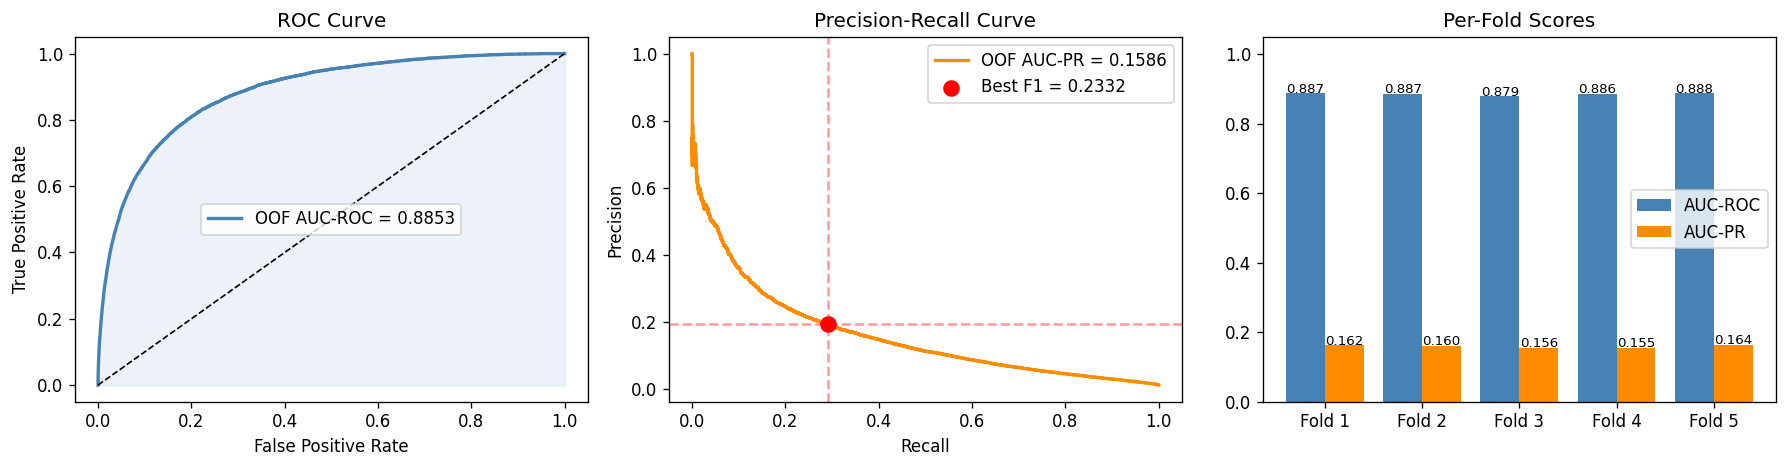

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y, oof_preds)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'OOF AUC-ROC = {oof_aucroc:.4f}')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# --- Precision-Recall Curve ---
axes[1].plot(recall_arr, precision_arr, color='darkorange', lw=2, label=f'OOF AUC-PR = {oof_aucpr:.4f}')
axes[1].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', s=80, zorder=5, label=f'Best F1 = {best_f1:.4f}')
axes[1].axvline(recall_arr[best_idx], color='red', linestyle='--', alpha=0.4)
axes[1].axhline(precision_arr[best_idx], color='red', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

# --- Per-Fold Scores ---
x_pos = np.arange(N_FOLDS)
axes[2].bar(x_pos - 0.2, fold_aucroc, width=0.4, label='AUC-ROC', color='steelblue')
axes[2].bar(x_pos + 0.2, fold_aucpr,  width=0.4, label='AUC-PR',  color='darkorange')
for i, (r, p) in enumerate(zip(fold_aucroc, fold_aucpr)):
    axes[2].text(i - 0.2, r + 0.002, f'{r:.3f}', ha='center', fontsize=8)
    axes[2].text(i + 0.2, p + 0.002, f'{p:.3f}', ha='center', fontsize=8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Per-Fold Scores')
axes[2].legend()

plt.tight_layout()
plt.show()

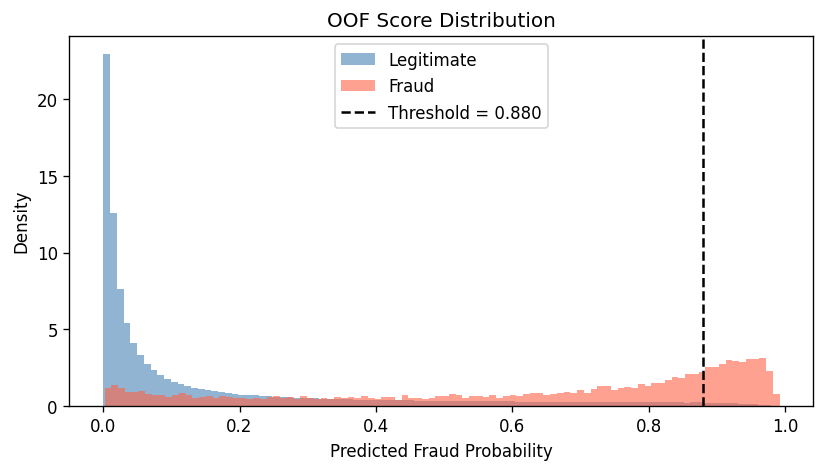

In [10]:
# OOF prediction distribution: how well separated are fraud vs legit scores?
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(oof_preds[y == 0], bins=100, density=True, alpha=0.6, label='Legitimate', color='steelblue')
ax.hist(oof_preds[y == 1], bins=100, density=True, alpha=0.6, label='Fraud',      color='tomato')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'Threshold = {best_threshold:.3f}')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Density')
ax.set_title('OOF Score Distribution')
ax.legend()
plt.show()

---
# 6. Feature Importance & SHAP
---

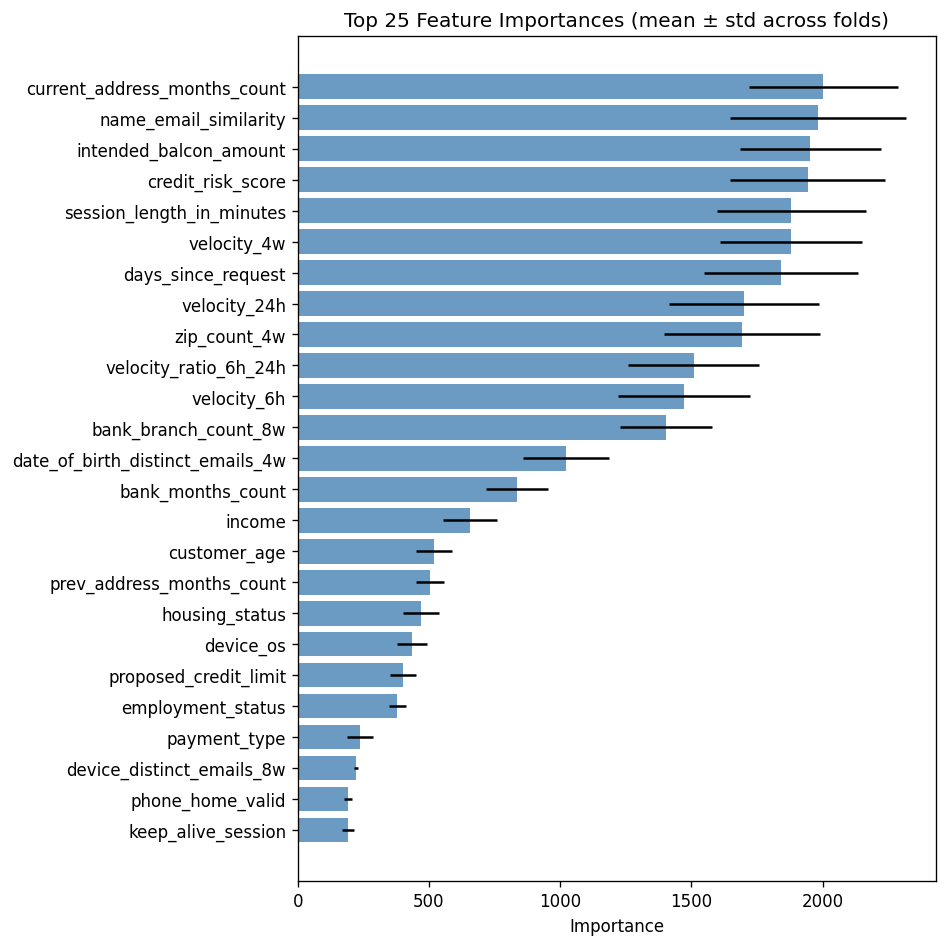

In [11]:
# Average feature importance across all folds
mean_imp = (
    importances.groupby('feature')['importance']
    .agg(['mean', 'std'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 8))
top_n = 25
ax.barh(
    mean_imp['feature'][:top_n][::-1],
    mean_imp['mean'][:top_n][::-1],
    xerr=mean_imp['std'][:top_n][::-1],
    color='steelblue', alpha=0.8
)
ax.set_title(f'Top {top_n} Feature Importances (mean ± std across folds)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

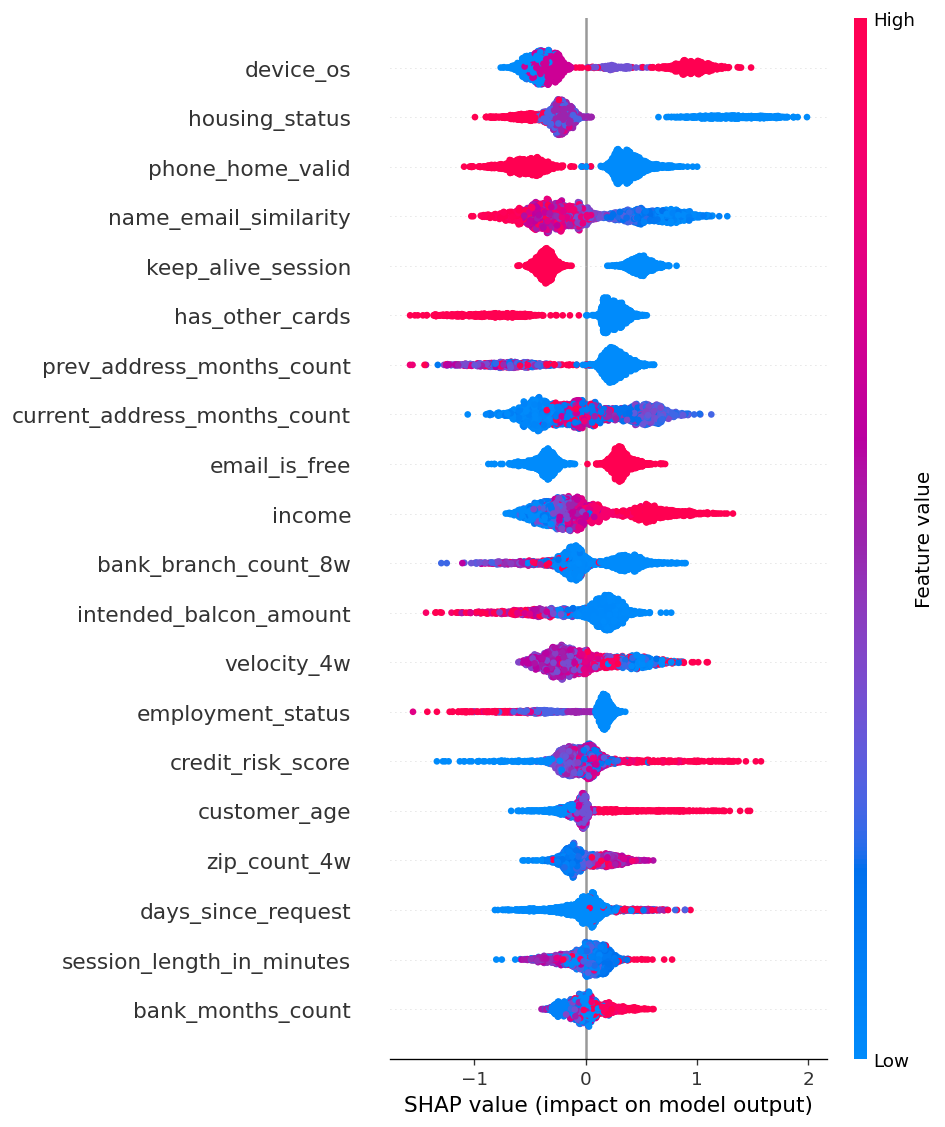

In [12]:
# SHAP values on a sample — use fold 1 model for efficiency
sample_idx = np.random.choice(len(X), size=2000, replace=False)
X_sample = X[sample_idx]

explainer   = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X_sample)

# shap_values may be a list [neg_class, pos_class] — take fraud class
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_sample, feature_names=FEATURES, max_display=20, show=True)

---
# 7. Variant Robustness Experiment
---

## 7. Variant Robustness Experiment

Train once on full Base → evaluate on all 6 datasets (Base held-out + 5 Variants).  
Each Variant introduces a different type of distribution shift:
- **Variant I**  : Resampling shift (fraud rate change)
- **Variant II** : Concept drift (fraud profiles change)
- **Variant III**: Temporal shift (time distribution change)
- **Variant IV** : Covariate shift (applicant feature distribution change)
- **Variant V**  : Combined shift

In [13]:
# Retrain on full Base with the same params (no CV split) for Variant evaluation
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(period=-1)])
print("Final model trained on full Base.")

Final model trained on full Base.


In [14]:
VARIANT_FILES = {
    'Base (CV OOF)'        : None,           # use OOF preds already computed
    'Variant I (Resample)' : 'Variant I.csv',
    'Variant II (Concept)' : 'Variant II.csv',
    'Variant III (Temporal)': 'Variant III.csv',
    'Variant IV (Covariate)': 'Variant IV.csv',
    'Variant V (Combined)' : 'Variant V.csv',
}


def evaluate_dataset(preds, labels, threshold):
    """Return a dict of evaluation metrics for a set of predictions."""
    return {
        'AUC-ROC': roc_auc_score(labels, preds),
        'AUC-PR' : average_precision_score(labels, preds),
        'F1'     : f1_score(labels, (preds >= threshold).astype(int)),
        'N'      : len(labels),
        'Fraud%' : labels.mean() * 100,
    }


variant_results = {}

for name, fname in VARIANT_FILES.items():
    if fname is None:
        # Base: use OOF predictions (honest estimate, no leakage)
        metrics = evaluate_dataset(oof_preds, y, best_threshold)
    else:
        # Load variant, apply the same preprocessing pipeline fitted on Base
        df_v = pd.read_csv(str(DATA_DIR / fname))
        df_v, _ = preprocess(df_v, encoder=encoder, fit=False)
        df_v    = feature_engineering(df_v)
        X_v     = df_v[FEATURES].values
        y_v     = df_v[TARGET].values
        preds_v = final_model.predict_proba(X_v)[:, 1]
        metrics = evaluate_dataset(preds_v, y_v, best_threshold)

    variant_results[name] = metrics
    print(f"{name:<30} | AUC-ROC: {metrics['AUC-ROC']:.4f} | AUC-PR: {metrics['AUC-PR']:.4f} | F1: {metrics['F1']:.4f}")

Base (CV OOF)                  | AUC-ROC: 0.8853 | AUC-PR: 0.1586 | F1: 0.2332
Variant I (Resample)           | AUC-ROC: 0.8854 | AUC-PR: 0.2404 | F1: 0.2944
Variant II (Concept)           | AUC-ROC: 0.8999 | AUC-PR: 0.2474 | F1: 0.3151
Variant III (Temporal)         | AUC-ROC: 0.8818 | AUC-PR: 0.2000 | F1: 0.2780
Variant IV (Covariate)         | AUC-ROC: 0.8983 | AUC-PR: 0.2298 | F1: 0.3011
Variant V (Combined)           | AUC-ROC: 0.8839 | AUC-PR: 0.2023 | F1: 0.2819


In [15]:
# Results table
results_df = pd.DataFrame(variant_results).T
results_df = results_df[['AUC-ROC', 'AUC-PR', 'F1', 'Fraud%', 'N']]
results_df['N'] = results_df['N'].astype(int)
display(results_df.style.format({'AUC-ROC': '{:.4f}', 'AUC-PR': '{:.4f}', 'F1': '{:.4f}', 'Fraud%': '{:.2f}%', 'N': '{:,}'}))

,AUC-ROC,AUC-PR,F1,Fraud%,N
Base (CV OOF),0.8853,0.1586,0.2332,1.10%,"1,000,000"
Variant I (Resample),0.8854,0.2404,0.2944,1.10%,"1,000,000"
Variant II (Concept),0.8999,0.2474,0.3151,1.10%,"1,000,000"
Variant III (Temporal),0.8818,0.2000,0.2780,1.10%,"1,000,000"
Variant IV (Covariate),0.8983,0.2298,0.3011,1.10%,"1,000,000"
Variant V (Combined),0.8839,0.2023,0.2819,1.10%,"1,000,000"


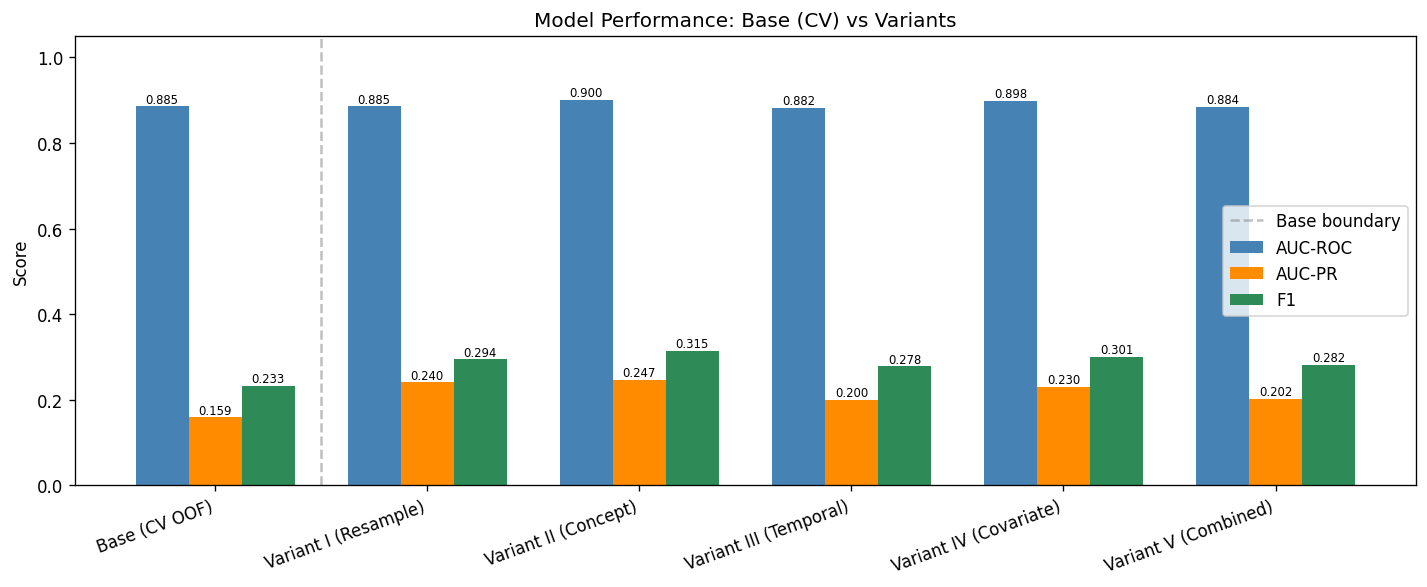

In [16]:
# Visualise performance degradation across variants
labels  = list(variant_results.keys())
aucroc  = [variant_results[k]['AUC-ROC'] for k in labels]
aucpr   = [variant_results[k]['AUC-PR']  for k in labels]
f1_vals = [variant_results[k]['F1']      for k in labels]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, aucroc,  width, label='AUC-ROC', color='steelblue')
bars2 = ax.bar(x,         aucpr,   width, label='AUC-PR',  color='darkorange')
bars3 = ax.bar(x + width, f1_vals, width, label='F1',      color='seagreen')

# Annotate bars
for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance: Base (CV) vs Variants')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Base boundary')
ax.legend()
plt.tight_layout()
plt.show()

---
# 8. Results Summary
---

In [17]:
base_aucpr = variant_results['Base (CV OOF)']['AUC-PR']

print("═" * 56)
print("   Bank Account Fraud (BAF) — Pipeline Results")
print("═" * 56)
print(f"  Model             : LightGBM ({N_FOLDS}-Fold Stratified CV)")
print(f"  Total features    : {len(FEATURES)}")
print(f"  Train samples     : {len(X):,}")
print(f"  Fraud rate        : {y.mean():.4%}")
print("─" * 56)
print(f"  OOF AUC-ROC       : {oof_aucroc:.5f}")
print(f"  OOF AUC-PR        : {oof_aucpr:.5f}")
print(f"  Best F1           : {best_f1:.5f} @ threshold {best_threshold:.4f}")
print(f"  CV AUC-ROC        : {np.mean(fold_aucroc):.5f} ± {np.std(fold_aucroc):.5f}")
print(f"  CV AUC-PR         : {np.mean(fold_aucpr):.5f} ± {np.std(fold_aucpr):.5f}")
print("─" * 56)
print("  Variant Robustness (AUC-PR drop vs Base):")
for name, res in variant_results.items():
    if name == 'Base (CV OOF)':
        continue
    drop = res['AUC-PR'] - base_aucpr
    print(f"  {name:<30} : {res['AUC-PR']:.4f} ({drop:+.4f})")
print("═" * 56)

════════════════════════════════════════════════════════
   Bank Account Fraud (BAF) — Pipeline Results
════════════════════════════════════════════════════════
  Model             : LightGBM (5-Fold Stratified CV)
  Total features    : 34
  Train samples     : 1,000,000
  Fraud rate        : 1.1029%
────────────────────────────────────────────────────────
  OOF AUC-ROC       : 0.88530
  OOF AUC-PR        : 0.15860
  Best F1           : 0.23320 @ threshold 0.8805
  CV AUC-ROC        : 0.88543 ± 0.00338
  CV AUC-PR         : 0.15949 ± 0.00357
────────────────────────────────────────────────────────
  Variant Robustness (AUC-PR drop vs Base):
  Variant I (Resample)           : 0.2404 (+0.0818)
  Variant II (Concept)           : 0.2474 (+0.0888)
  Variant III (Temporal)         : 0.2000 (+0.0414)
  Variant IV (Covariate)         : 0.2298 (+0.0712)
  Variant V (Combined)           : 0.2023 (+0.0437)
════════════════════════════════════════════════════════


---
# 9. Model Export
---

Save all trained models and artifacts using `joblib` with `.joblib` extension.

In [18]:
# Convert string to a Path object
MODEL_DIR = Path('../../models') 

# Ensure the directory exists
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save all 5 fold models — used for ensemble averaging at inference time
for i, fold_model in enumerate(models, 1):
    joblib.dump(fold_model, MODEL_DIR / f'baf_lgbm_fold{i}.joblib')
    print(f'Saved baf_lgbm_fold{i}.joblib')

# Save the final model trained on full Base — used for Variant evaluation
joblib.dump(final_model, MODEL_DIR / 'baf_lgbm_final.joblib')
print('Saved baf_lgbm_final.joblib')

# Save the OrdinalEncoder fitted on Base — must use same encoder at inference
joblib.dump(encoder, MODEL_DIR / 'baf_encoder.joblib')
print('Saved baf_encoder.joblib')

# Save the optimal threshold
joblib.dump(
    {'threshold': best_threshold, 'features': FEATURES},
    MODEL_DIR / 'baf_artifacts.joblib'
)
print(f'Saved baf_artifacts.joblib  (threshold={best_threshold:.4f})')

print(f'\nAll BAF artifacts saved to {MODEL_DIR}')

Saved baf_lgbm_fold1.joblib
Saved baf_lgbm_fold2.joblib
Saved baf_lgbm_fold3.joblib
Saved baf_lgbm_fold4.joblib
Saved baf_lgbm_fold5.joblib
Saved baf_lgbm_final.joblib
Saved baf_encoder.joblib
Saved baf_artifacts.joblib  (threshold=0.8805)

All BAF artifacts saved to ../../models
